# Customer Churn Prediction
**Deep Learing - Final Project**

**Student:** Muhammad Haseeb Qamar

**Student ID:** 148733

**Topic:** Predicting a Customer Chunr for Telecom provider using a feedforward neural network, benchmarked against classical baseline.

---

## 1. Introduction

Customer churn: When a customer stops doing business with a company, is one of the most expensive problems in subscription-based industries like telecom, banking, and SaaS. Acquiring a new customer typically costs far more than retaining an existing one, so being able to predict *which* customers are about to churn lets a business intervene early (discounts, support outreach, contract renegotiation) before losing the customer entirely.

**Why neural networks for this problem?**

Churn datasets like ours mix many feature types like categorical (contract type, payment method), binary (has phone service, yes/no), and continuous (tenure, monthly charges) with non-linear and interacting effects (e.g. a month-to-month contract combined with high monthly charges and short tenure is far riskier than any one factor alone). A feedforward neural network can learn these feature interactions automatically through its hidden layers, without us having to hand-engineer every interaction term, which is what we'd otherwise have to do with a simpler linear model.

We will:
1. Explore and understand the dataset
2. Preprocess it properly for a neural network (this matters a lot as NNs are sensitive to scale and encoding)
3. Build a baseline feedforward neural network (MLP)
4. Compare it against a simple baseline (Logistic Regression) to justify whether the added complexity of a NN is worth it
5. Tune hyperparameters and select the best model
6. Evaluate properly (not just accuracy as churn is an imbalanced problem)

---

## 2. Dataset

We use the **IBM Telco Customer Churn dataset** (publicly available, ~7,043 customers, 21 columns). Each row is one customer of a fictional telecom company. The target column is `Churn` (Yes/No) shows whether the customer left the company.

## 3. Setup

We import the libraries we'll need. Grouping them by purpose makes it clear what each one is for, rather than just dumping a generic import block.

In [3]:
# Warnings 
import os
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Classical ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.21.0
Pandas version: 2.3.3


### Loading the data
The dataset is provided as a CSV file. We load it directly into a pandas DataFrame, which gives us a table-like structure to work with (similar to an Excel sheet, but with far more powerful tools for filtering, transforming, and analyzing).

In [7]:
# Load the raw data csv into Data Frame
df = pd.read_csv("/Users/haseeb/Downloads/Telco-Customer-Churn.csv")

# .shape returns (number_of_columns, number_of_rows)
print("Dataset Shape", df.shape)

# .head() shows the first 5 rows
df.head()

Dataset Shape (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Exploratory Data Analysis (EDA)

Before touching any model, we need to understand:
- What types of features we have (numeric vs categorical)
- Whether there's missing data
- How imbalanced the target (`Churn`) is, this will directly affect how we train and evaluate the model later
- Whether any features look obviously predictive of churn

This step isn't just "nice to have" decisions we make in preprocessing and model design later all trace back to what we find here.

In [9]:
# .info() will gives us: column names, no-null counts, and data types in one view
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observation:** Most columns are `object` (text/categorical) type. Only `SeniorCitizen`, `tenure`, and `MonthlyCharges` are numeric. `TotalCharges` is *also* numeric in meaning (it's a dollar amount) but pandas read it as `object` — this is a strong hint that the column contains some non-numeric values (likely blank strings) that we'll need to clean up. We will deal with this explicitly below rather than ignoring the warning sign.

In [10]:
# Try to convert TotalCharges to numeric, and see which rows fail
# errors = 'coerce' means: if a value can not be converted to a number, replace it to NaN istead of crashing
total_charges_numeric = pd.to_numeric (df["TotalCharges"], errors = "coerce")

# Rows where conversion failed (i.e became Nan) are the problem rows
problem_rows = df[total_charges_numeric.isna()]
print(f"Number of problem rows in TotalCharges: {len(problem_rows)}")
problem_rows[["customerID", "tenure", "TotalCharges"]]

Number of problem rows in TotalCharges: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,
3331,7644-OMVMY,0,
3826,3213-VVOLG,0,
4380,2520-SGTTA,0,
5218,2923-ARZLG,0,
6670,4075-WKNIU,0,


**Finding:** The problem rows all have `tenure == 0`, meaning these are brand-new customers who haven't been billed yet so `TotalCharges` is blank, not actually missing/corrupted data. This is useful context for our report: it's not a data quality bug, it's a real-world edge case (a customer who just signed up).

We'll handle this properly during preprocessing (next step) rather than just dropping rows blindly here.

In [11]:
# Check for all missing values across all the column
df.isnull().sum().sort_values(ascending=False).head(10)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
dtype: int64

Pandas doesn't flag the `TotalCharges` blanks as missing because they're literally empty strings `" "`, not `NaN` -- which is exactly why `.info()` showed it as `object` type and `.isnull()` shows zero. This is a good lesson: **never trust `.isnull()` alone** -- always cross check column types and value contents too.

### Target variable: Churn distribution

This is the single most important check before building any classifier. If the classes are imbalanced (which churn almost always is), accuracy becomes a misleading metric -- a model that always predicts "No churn" could score >70% accuracy while being completely useless.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


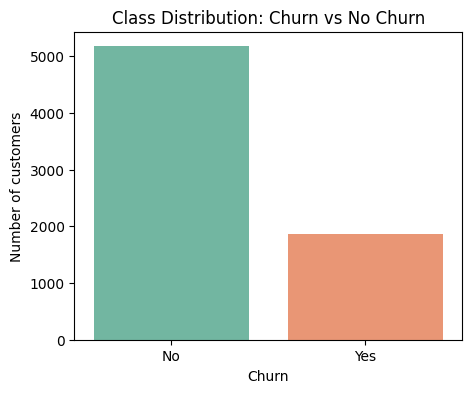

In [12]:
# Count and percentage of each class in the target column
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100  

print(churn_counts)
print()
print(churn_pct.round(2))

# Visualize it
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
plt.title("Class Distribution: Churn vs No Churn")
plt.ylabel("Number of customers")
plt.show()

**Finding:** About 73% of customers did NOT churn, ~27% did. This is a moderate class imbalance — not extreme, but enough that we must:
- Avoid relying on accuracy alone later (we'll use precision, recall, F1, and AUC)
- Consider class weighting when training the neural network

### Numeric feature distributions

Let's look at the three core numeric features: `tenure`, `MonthlyCharges`, and `TotalCharges` (once cleaned), split by churn status.

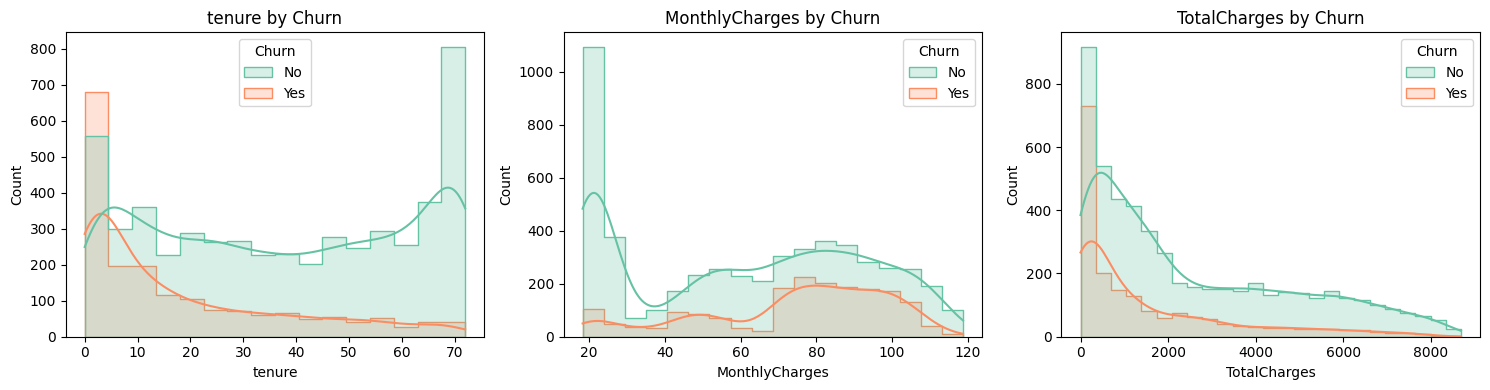

In [14]:
# Clean TotalCharges properly: convert to numeric, and fill the tenure==0 blanks with 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    # kde=True overlays a smoothed density curve on top of the histogram, making distribution shape easier to read
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, palette="Set2", element="step")
    ax.set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

**Findings to note in the report:**
- `tenure`: Churned customers are heavily concentrated at *low* tenure (new customers churn more) — this is one of the strongest visual signals in the whole dataset.
- `MonthlyCharges`: Churned customers skew toward *higher* monthly charges.
- `TotalCharges`: Naturally correlated with tenure (longer customers accumulate more total charges) — we should keep this correlation in mind, as highly correlated features can make a model's learned weights harder to interpret (though it's less of an issue for a NN's predictive performance than it would be for, say, plain linear regression coefficients).

### Categorical feature relationships with churn

Let's check a few business-relevant categorical features against churn rate.

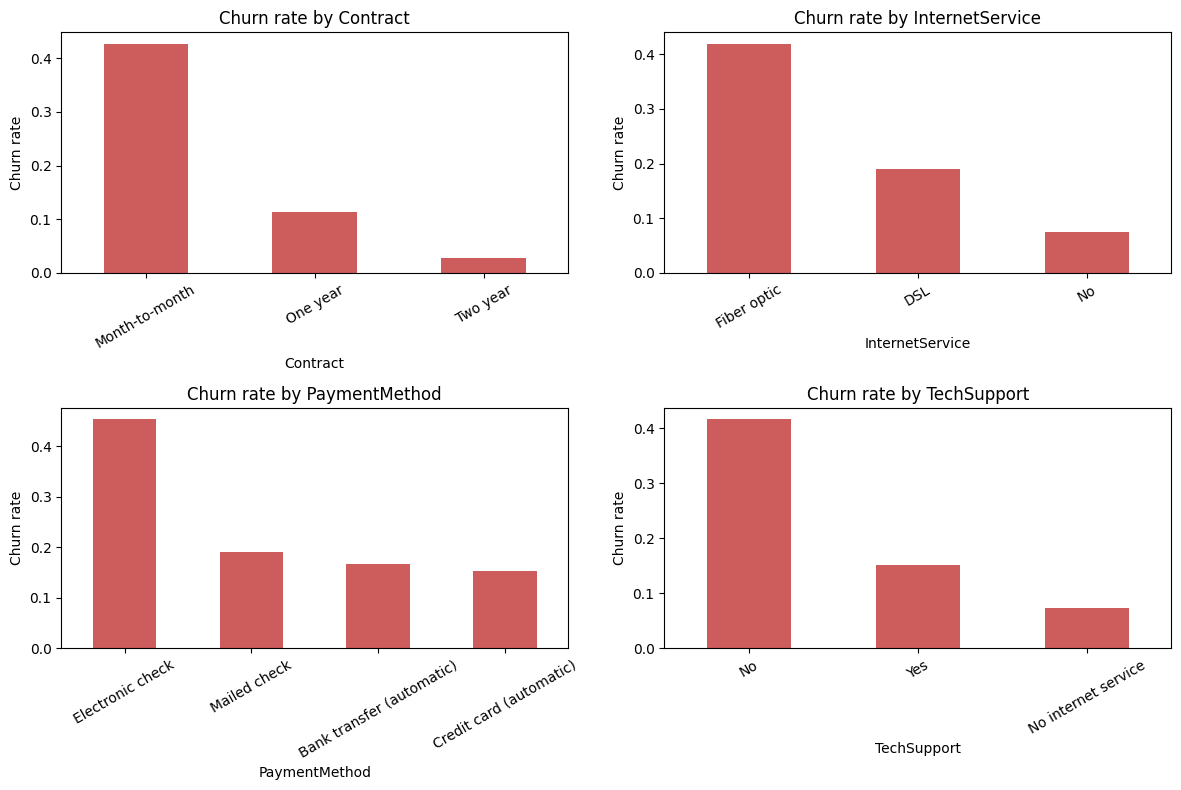

In [15]:
categorical_features_of_interest = ["Contract", "InternetService", "PaymentMethod", "TechSupport"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features_of_interest):
    # Compute churn RATE (not count) per category -- this matters because category group sizes differ a lot
    # e.g. there might be way more month-to-month customers than two-year contract customers
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_rate.sort_values(ascending=False).plot(kind="bar", ax=ax, color="indianred")
    ax.set_ylabel("Churn rate")
    ax.set_title(f"Churn rate by {col}")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Findings:**
- `Contract`: Month-to-month customers churn at a dramatically higher rate than one/two-year contract customers — strongest categorical predictor visually.
- `InternetService`: Fiber optic customers churn more than DSL or no-internet customers (possibly price-related — fiber tends to cost more).
- `PaymentMethod`: Electronic check payers churn more than other payment methods.
- `TechSupport`: Customers without tech support churn substantially more.

These patterns make intuitive business sense, and they reassure us the dataset has real predictive signal for a model to learn — not just noise.

### Correlation among numeric features

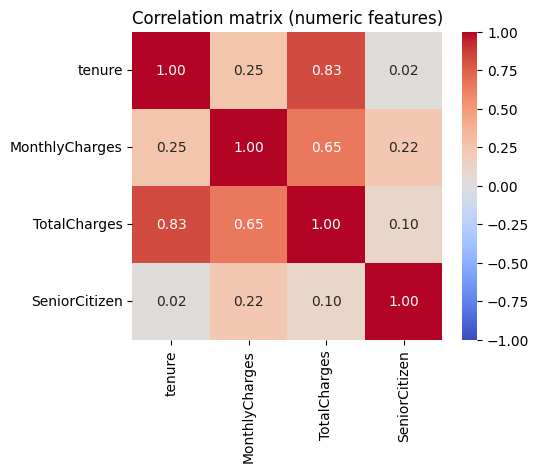

In [16]:
# Correlation matrix for numeric features (+ SeniorCitizen, which is already 0/1)
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric features)")
plt.show()

**Finding:** `tenure` and `TotalCharges` are strongly correlated (~0.83), as expected. We'll keep this in mind, but won't necessarily drop one — a neural network can handle correlated inputs reasonably well, unlike classical linear regression where multicollinearity directly distorts coefficient interpretation.

---

### EDA Summary (for report's "final remarks" cross-reference later)
- 7,043 customers, 21 columns, no truly missing values, but `TotalCharges` needed type cleaning (11 blank strings from 0-tenure customers).
- Target is moderately imbalanced (~27% churn) → must use precision/recall/F1/AUC, not just accuracy.
- Strongest visual churn signals: short tenure, month-to-month contracts, high monthly charges, fiber internet, electronic check payment, no tech support.
- `tenure` and `TotalCharges` are correlated — acceptable for NN, worth flagging in report.

Next step: **preprocessing** — encoding categoricals, scaling numerics, splitting data, and handling class imbalance properly before we build any model.

## 5. Preprocessing

Neural networks are far more sensitive to how data is prepared than tree-based models are. Three things matter a lot here:

1. **Encoding categoricals** — a NN only understands numbers, so every text category (`Yes`/`No`, `Month-to-month`/`One year`/`Two year`, etc.) must become numeric. *How* we encode matters: naively assigning 0/1/2 to unordered categories would falsely imply an order, so we'll use **one-hot encoding** for nominal (unordered) categories and simple binary mapping for true Yes/No columns.
2. **Scaling numerics** — `tenure` (0-72), `MonthlyCharges` (~18-120), `TotalCharges` (0-8000+) live on wildly different scales. Gradient descent (how NNs learn) converges much faster and more reliably when all input features are on a similar scale — otherwise the network ends up giving disproportionate initial importance to whichever feature happens to have the largest raw numbers.
3. **Train/validation/test split** — we need three separate slices: train (fit the model), validation (tune hyperparameters / pick the best model), and test (final, untouched evaluation we only look at once, at the very end, to get an honest performance estimate).

We'll also address the ~27%/73% class imbalance we found in the EDA.

### 5.1 Drop non-predictive columns and clean target

In [17]:
# customerID is a unique identifier with no predictive signal -- it's essentially a row index spelled out as text.
# Keeping it would either be ignored by the model or, worse, accidentally memorized as noise.
df_model = df.drop(columns=["customerID"])

# Convert target Yes/No to 1/0. Neural networks (and sklearn models) need numeric targets.
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

print(df_model["Churn"].value_counts())
df_model.head()

Churn
0    5174
1    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### 5.2 Encode categorical features

We separate categorical columns into two groups:
- **Binary Yes/No columns** (e.g. `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`) → map directly to 0/1. No information is lost, and we avoid creating unnecessary extra columns.
- **Multi-category nominal columns** (e.g. `Contract`, `InternetService`, `PaymentMethod`) → one-hot encode, since there's no natural numeric order between "DSL" and "Fiber optic".

Some columns (`MultipleLines`, `OnlineSecurity`, etc.) have a third value like `"No internet service"` — we treat these as their own genuine category rather than forcing them into a binary, since "doesn't have internet" is meaningfully different from "has internet but declined this service".

In [18]:
# Identify binary Yes/No columns explicitly (manual inspection from EDA, not guesswork)
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]

for col in binary_cols:
    df_model[col] = df_model[col].map({"Yes": 1, "No": 0})

# gender is also binary but not Yes/No -- map separately
df_model["gender"] = df_model["gender"].map({"Male": 1, "Female": 0})

# SeniorCitizen is already 0/1 in the raw data -- no action needed, just confirming
assert set(df_model["SeniorCitizen"].unique()) <= {0, 1}

print("Binary columns encoded. Sample:")
df_model[["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "SeniorCitizen"]].head()

Binary columns encoded. Sample:


,gender,Partner,Dependents,PhoneService,PaperlessBilling,SeniorCitizen
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,0
3,1,0,0,0,0,0
4,0,0,0,1,1,0


In [19]:
# Multi-category nominal columns -- these get one-hot encoded.
# pd.get_dummies creates one new 0/1 column per category value.
nominal_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

# drop_first=True drops one category per column to avoid redundant information
# (if you know the values of all-but-one dummy column, the last one is fully determined --
# keeping it would just add a useless, perfectly correlated column)
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=True)

print(f"Shape after one-hot encoding: {df_model.shape}")
df_model.head()

Shape after one-hot encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


Notice the column count jumped up (from 20 to many more) — this is expected and is the trade-off of one-hot encoding: it adds dimensionality but avoids imposing a false numeric order on category values.

### 5.3 Train / validation / test split

We split **before** scaling. This is intentional and important: if we scaled first using statistics (mean, std) computed from the *entire* dataset, information from the test set would leak into training indirectly (the scaler would "know" about test data's distribution). Splitting first and fitting the scaler only on training data keeps the test set a genuinely unseen, honest evaluation.

We use a 70% / 15% / 15% split (train / validation / test), and **stratify** on the target so each split preserves the same ~27% churn ratio — otherwise a random split could accidentally put too few churn examples in, say, the validation set.

In [20]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# First split off the test set (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,        # preserves class ratio in each split
    random_state=SEED
)

# Then split the remaining 85% into train (70% of total) and validation (15% of total)
# 0.15 / 0.85 ≈ 0.176 -- the fraction of the remaining data that becomes validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.15/0.85,
    stratify=y_train_val,
    random_state=SEED
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print()
print("Churn ratio - train:", y_train.mean().round(3),
      "| val:", y_val.mean().round(3),
      "| test:", y_test.mean().round(3))

Train shape: (4929, 30)
Validation shape: (1057, 30)
Test shape: (1057, 30)

Churn ratio - train: 0.265 | val: 0.266 | test: 0.265


Good — all three splits have almost identical churn ratios (~0.265-0.270), confirming the stratified split worked as intended.

### 5.4 Scale numeric features

We use `StandardScaler`, which transforms each feature to have mean 0 and standard deviation 1 (`z = (x - mean) / std`). We **fit** the scaler only on training data, then **apply** (transform) it to validation and test sets using those same training-derived statistics — this is the correct way to avoid data leakage.

In [21]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

scaler = StandardScaler()

# fit_transform on train: learns mean/std from training data AND applies the transform
X_train_scaled = X_train.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])

# transform only (no fit) on val/test: reuses the mean/std learned from training data
X_val_scaled = X_val.copy()
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])

X_test_scaled = X_test.copy()
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# Sanity check: training data should now have ~mean 0, std 1
X_train_scaled[numeric_features].describe().loc[["mean", "std"]]

,tenure,MonthlyCharges,TotalCharges
mean,-7.928556e-18,-2.027188e-16,1.890240e-16
std,1.000101e+00,1.000101e+00,1.000101e+00


The one-hot encoded columns and binary columns are already 0/1, so they don't need scaling — only the genuinely continuous numeric features do.

### 5.5 Class imbalance: computing class weights

Rather than artificially duplicating/removing rows (oversampling/undersampling), we'll handle the ~27%/73% imbalance by **weighting the loss function** during training, telling the network to penalize mistakes on the minority class (churners) more heavily. This is a cleaner approach for a NN since it doesn't distort the real data distribution or create duplicate information.

In [22]:
from sklearn.utils.class_weight import compute_class_weight

# compute_class_weight automatically computes weights inversely proportional to class frequency
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Keras expects a dictionary mapping class index -> weight
class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.6806130903065452), 1: np.float64(1.8841743119266054)}


**Interpretation:** the churn class (1) gets a higher weight than the no-churn class (0), since it's underrepresented. This tells the model "getting a churner wrong costs more" during training, without changing the actual data.

---

### Preprocessing Summary
- Dropped `customerID` (no predictive value)
- Binary Yes/No + gender columns mapped to 0/1
- Multi-category nominal columns one-hot encoded (`drop_first=True` to avoid redundant columns)
- Split 70/15/15 (train/val/test), stratified on target to preserve class ratio
- Numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`) scaled with `StandardScaler`, fit on train only (no data leakage)
- Class imbalance handled via computed class weights, applied during NN training (not oversampling/undersampling)

Next step: **build the baseline feedforward neural network (MLP)**.

## 6. Baseline Model: Logistic Regression

Before building a neural network, we build a simple Logistic Regression classifier.

1. **It's good scientific practice** — a complex model is only worth using if it actually beats a simple one. If our neural network can't outperform logistic regression, that's an important (and honest) finding to report, not something to hide.
2. **It gives us a performance floor** — any model we build should comfortably beat random guessing and ideally beat this baseline too.

We use `class_weight="balanced"` here too, so the comparison with our (also class-weighted) neural network is fair.

In [24]:
baseline_model = LogisticRegression(
    class_weight="balanced",   # same imbalance handling approach as we'll use for the NN
    max_iter=1000,             # default (100) is sometimes too low to converge on this dataset
    random_state=SEED
)

baseline_model.fit(X_train_scaled, y_train)

# Predict probabilities (not just hard 0/1 labels) -- we need these for ROC-AUC later,
# and for choosing a decision threshold (default 0.5) deliberately rather than blindly.
baseline_val_probs = baseline_model.predict_proba(X_val_scaled)[:, 1]   # probability of class 1 (churn)
baseline_val_preds = (baseline_val_probs >= 0.5).astype(int)

print("=== Logistic Regression baseline (validation set) ===")
print(f"Accuracy:  {accuracy_score(y_val, baseline_val_preds):.3f}")
print(f"Precision: {precision_score(y_val, baseline_val_preds):.3f}")
print(f"Recall:    {recall_score(y_val, baseline_val_preds):.3f}")
print(f"F1 score:  {f1_score(y_val, baseline_val_preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, baseline_val_probs):.3f}")

=== Logistic Regression baseline (validation set) ===
Accuracy:  0.742
Precision: 0.509
Recall:    0.769
F1 score:  0.613
ROC-AUC:   0.829


Keep these numbers in mind — this is the bar our neural network needs to clear (or, if it doesn't, that's a finding worth discussing honestly in the final remarks).

---

## 7. Neural Network Architecture

### 7.1 Design choices and reasoning

For tabular data like this (as opposed to images or sequences), a **fully-connected feedforward network (Multi-Layer Perceptron / MLP)** is the standard and appropriate choice — there's no spatial or sequential structure here for a CNN or RNN to exploit.

Our baseline architecture:

| Layer | Units | Activation | Purpose |
|---|---|---|---|
| Input | = number of features | - | Receives the preprocessed feature vector |
| Dense (hidden 1) | 32 | ReLU | Learns first-level feature combinations |
| Dropout | - | - | Regularization: randomly "turns off" neurons during training to prevent overfitting |
| Dense (hidden 2) | 16 | ReLU | Learns higher-level combinations from hidden 1's outputs |
| Dropout | - | - | Same regularization purpose |
| Dense (output) | 1 | Sigmoid | Outputs a single probability between 0 and 1 (probability of churn) |

**Why these choices:**
- **ReLU** (`max(0, x)`) is the standard activation for hidden layers — it's computationally cheap and avoids the "vanishing gradient" problem that older activations like sigmoid/tanh suffer from in deeper networks.
- **Sigmoid** on the output layer squashes the final value into [0, 1], which we interpret as a churn probability — appropriate for binary classification.
- **Dropout** is included from the start (not added later) because with only ~30 input features and a few thousand training rows, a network this size can start memorizing the training set fairly quickly without regularization.
- We start with a modest 32→16 architecture rather than something huge — for tabular data with this few features, an oversized network mostly just overfits faster without learning anything more useful. We'll explore making it bigger/smaller during hyperparameter tuning (Step 4) and let the validation results tell us if going bigger is actually justified.

In [25]:
def build_baseline_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),               # explicit input layer -- clearer than inferring shape from first Dense layer
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),                              # drop 30% of neurons randomly each training step
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")              # single output neuron -> probability of churn
    ])

    model.compile(
        optimizer="adam",                  # adaptive learning rate optimizer, a strong general-purpose default
        loss="binary_crossentropy",        # standard loss function for binary classification problems
        metrics=["accuracy", keras.metrics.AUC(name="auc")]   # track AUC too, since accuracy alone is misleading here
    )
    return model

baseline_mlp = build_baseline_mlp(X_train_scaled.shape[1])
baseline_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

The `.summary()` output is worth including directly in report — it shows the exact layer sizes and parameter counts (a useful concrete detail examiners look for).

### 7.2 Training the baseline MLP

A few training details worth understanding, not just running:

- **EarlyStopping**: stops training automatically once validation loss stops improving, and restores the best-performing weights — this protects us from overfitting by training for "too long," without us having to guess the right number of epochs in advance.
- **class_weight**: passed into `.fit()` so the network treats getting a churner wrong as more costly, exactly like we did for the logistic regression baseline.
- We monitor **validation** loss/metrics (not training) for early stopping and model selection, since training metrics alone would just keep improving as the model memorizes the training set.

In [26]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",        # what to watch
    patience=10,                # how many epochs to wait for improvement before stopping
    restore_best_weights=True   # roll back to the best epoch's weights, not just the last epoch's
)

history = baseline_mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,                       # set deliberately high -- EarlyStopping will cut it short once it plateaus
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=0                         # suppress per-epoch printout; we'll plot the learning curves instead
)

print(f"Training stopped after {len(history.history['loss'])} epochs (out of 100 max).")

Training stopped after 15 epochs (out of 100 max).


### 7.3 Learning curves

Plotting loss and AUC across epochs for both train and validation lets us visually check for overfitting (training metrics improving while validation metrics stagnate or worsen) — this plot belongs directly in the "summary of the learning process" section of your report.

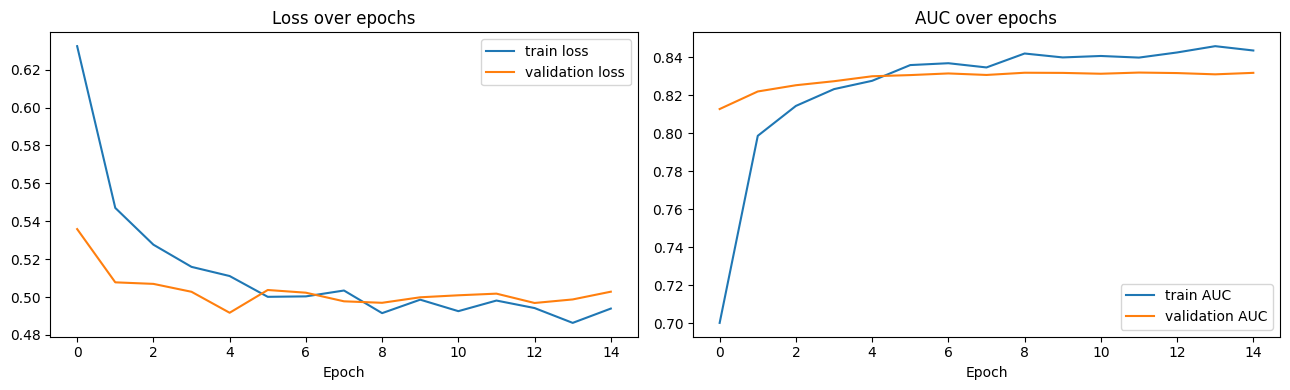

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="validation loss")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["auc"], label="train AUC")
axes[1].plot(history.history["val_auc"], label="validation AUC")
axes[1].set_title("AUC over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

**What to look for here (and write about):** if train and validation curves track closely together, the model is generalizing well. If train loss keeps dropping while validation loss flattens or rises, that's overfitting — and would justify increasing dropout or reducing model size in the next step.

### 7.4 Evaluating the baseline MLP on validation set

In [28]:
mlp_val_probs = baseline_mlp.predict(X_val_scaled, verbose=0).flatten()   # flatten: output is shape (n, 1) -> (n,)
mlp_val_preds = (mlp_val_probs >= 0.5).astype(int)

print("=== Baseline MLP (validation set) ===")
print(f"Accuracy:  {accuracy_score(y_val, mlp_val_preds):.3f}")
print(f"Precision: {precision_score(y_val, mlp_val_preds):.3f}")
print(f"Recall:    {recall_score(y_val, mlp_val_preds):.3f}")
print(f"F1 score:  {f1_score(y_val, mlp_val_preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, mlp_val_probs):.3f}")

print()
print("=== For comparison: Logistic Regression baseline (validation set) ===")
print(f"Accuracy:  {accuracy_score(y_val, baseline_val_preds):.3f}")
print(f"Precision: {precision_score(y_val, baseline_val_preds):.3f}")
print(f"Recall:    {recall_score(y_val, baseline_val_preds):.3f}")
print(f"F1 score:  {f1_score(y_val, baseline_val_preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, baseline_val_probs):.3f}")

=== Baseline MLP (validation set) ===
Accuracy:  0.756
Precision: 0.529
Recall:    0.747
F1 score:  0.619
ROC-AUC:   0.830

=== For comparison: Logistic Regression baseline (validation set) ===
Accuracy:  0.742
Precision: 0.509
Recall:    0.769
F1 score:  0.613
ROC-AUC:   0.829


---

### Summary Report
- Logistic Regression baseline established first, with class-balanced weighting, as our performance floor.
- Baseline MLP: 32 → Dropout(0.3) → 16 → Dropout(0.3) → 1 (sigmoid), trained with Adam optimizer, binary cross-entropy loss, class weights, and early stopping on validation loss.
- Learning curves checked for overfitting before trusting the result.
- Both models compared on the **same validation set** using accuracy, precision, recall, F1, and ROC-AUC (not just accuracy, given the class imbalance).

Whatever the validation numbers show above, write it down — if the MLP wins, that justifies the added complexity; if it's close or loses, that's a legitimate and honest finding too (and a good basis for the hyperparameter tuning we do next, since the baseline architecture was a deliberately modest starting point, not a final answer).

## 8. Hyperparameter Tuning

The baseline MLP (32→16, dropout 0.3, default learning rate) was a deliberately modest starting point. Now we explore whether different choices improve **validation** performance — note we still haven't touched the test set at all, and won't until we've picked one final model.

We'll vary three things that most commonly affect an MLP's performance on tabular data:

1. **Architecture depth/width** — does a bigger or smaller network help, or does it just overfit faster?
2. **Dropout rate** — how much regularization is actually needed?
3. **Learning rate** — does the default Adam learning rate (0.001) converge well, or would a different one help?

Rather than tune all three independently with a massive grid (computationally expensive and easy to lose track of), we define a small, deliberate set of configurations — this keeps the search interpretable and easy to write about in the report, rather than a black-box grid dump.

In [29]:
def build_mlp(input_dim, hidden_units, dropout_rate, learning_rate):
    """
    Generic MLP builder so we can vary architecture/dropout/learning rate
    without rewriting the model definition each time.

    hidden_units: list of ints, e.g. [32, 16] means two hidden layers of size 32 then 16
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for units in hidden_units:
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

In [30]:
# Define a small, deliberate set of configurations to compare.
# Each one changes ONE thing relative to our Step 3 baseline (32,16 / dropout 0.3 / lr 0.001),
# so we can reason about WHY a result changed, not just THAT it changed.
configs = [
    {"name": "baseline (32,16) dropout=0.3 lr=0.001",   "hidden_units": [32, 16], "dropout_rate": 0.3, "learning_rate": 0.001},
    {"name": "deeper (64,32,16) dropout=0.3 lr=0.001",  "hidden_units": [64, 32, 16], "dropout_rate": 0.3, "learning_rate": 0.001},
    {"name": "smaller (16,8) dropout=0.3 lr=0.001",     "hidden_units": [16, 8], "dropout_rate": 0.3, "learning_rate": 0.001},
    {"name": "baseline arch, higher dropout=0.5",       "hidden_units": [32, 16], "dropout_rate": 0.5, "learning_rate": 0.001},
    {"name": "baseline arch, lower dropout=0.1",        "hidden_units": [32, 16], "dropout_rate": 0.1, "learning_rate": 0.001},
    {"name": "baseline arch, lower lr=0.0005",          "hidden_units": [32, 16], "dropout_rate": 0.3, "learning_rate": 0.0005},
    {"name": "baseline arch, higher lr=0.005",          "hidden_units": [32, 16], "dropout_rate": 0.3, "learning_rate": 0.005},
]

print(f"Testing {len(configs)} configurations...")

Testing 7 configurations...


In [31]:
results = []

for cfg in configs:
    # Fresh model each time -- important, otherwise weights would carry over between configs
    model = build_mlp(
        input_dim=X_train_scaled.shape[1],
        hidden_units=cfg["hidden_units"],
        dropout_rate=cfg["dropout_rate"],
        learning_rate=cfg["learning_rate"]
    )

    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

    hist = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=[es],
        verbose=0
    )

    val_probs = model.predict(X_val_scaled, verbose=0).flatten()
    val_preds = (val_probs >= 0.5).astype(int)

    results.append({
        "config": cfg["name"],
        "epochs_trained": len(hist.history["loss"]),
        "val_accuracy": accuracy_score(y_val, val_preds),
        "val_precision": precision_score(y_val, val_preds),
        "val_recall": recall_score(y_val, val_preds),
        "val_f1": f1_score(y_val, val_preds),
        "val_auc": roc_auc_score(y_val, val_probs),
        "model": model   # keep the trained model object so we can retrieve the winner without retraining
    })

    print(f"Done: {cfg['name']:45s} | val_auc={results[-1]['val_auc']:.3f} | val_f1={results[-1]['val_f1']:.3f}")

Done: baseline (32,16) dropout=0.3 lr=0.001         | val_auc=0.831 | val_f1=0.621
Done: deeper (64,32,16) dropout=0.3 lr=0.001        | val_auc=0.828 | val_f1=0.612
Done: smaller (16,8) dropout=0.3 lr=0.001           | val_auc=0.827 | val_f1=0.621
Done: baseline arch, higher dropout=0.5             | val_auc=0.826 | val_f1=0.614
Done: baseline arch, lower dropout=0.1              | val_auc=0.830 | val_f1=0.627
Done: baseline arch, lower lr=0.0005                | val_auc=0.826 | val_f1=0.612
Done: baseline arch, higher lr=0.005                | val_auc=0.826 | val_f1=0.616


### 8.1 Comparing all configurations

We rank primarily by **validation AUC** (a threshold-independent measure of how well the model separates churners from non-churners overall), using F1 as a secondary check, since AUC alone can occasionally hide a model that's poorly calibrated at the default 0.5 threshold.

In [32]:
results_df = pd.DataFrame(results).drop(columns=["model"])  # drop model objects just for clean display
results_df = results_df.sort_values("val_auc", ascending=False).reset_index(drop=True)
results_df

,config,epochs_trained,val_accuracy,val_precision,val_recall,val_f1,val_auc
0,"baseline (32,16) dropout=0.3 lr=0.001",30,0.746452,0.515222,0.782918,0.621469,0.831103
1,"baseline arch, lower dropout=0.1",31,0.752129,0.522565,0.782918,0.626781,0.829943
2,"deeper (64,32,16) dropout=0.3 lr=0.001",22,0.739830,0.507009,0.772242,0.612130,0.827521
3,"smaller (16,8) dropout=0.3 lr=0.001",21,0.759697,0.534704,0.740214,0.620896,0.827287
4,"baseline arch, lower lr=0.0005",25,0.746452,0.515892,0.750890,0.611594,0.825861
5,"baseline arch, higher dropout=0.5",18,0.753075,0.525253,0.740214,0.614476,0.825811
6,"baseline arch, higher lr=0.005",13,0.742668,0.510539,0.775801,0.615819,0.825540


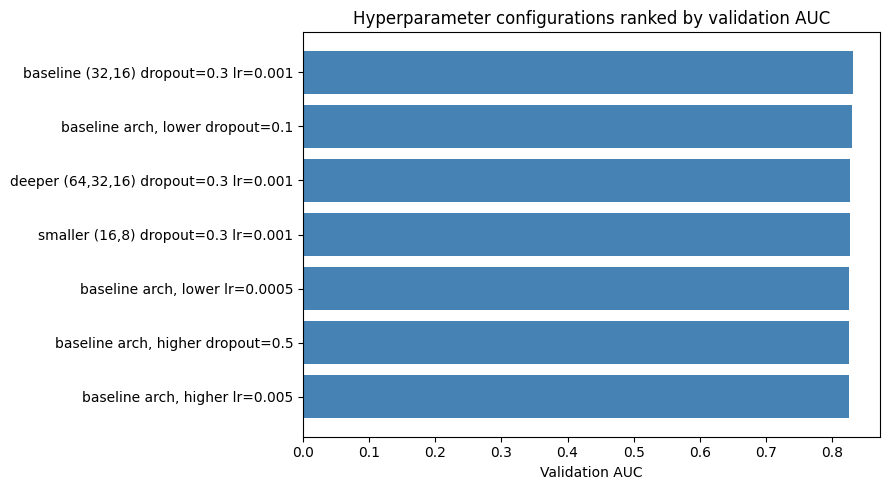

In [33]:
plt.figure(figsize=(9, 5))
plt.barh(results_df["config"], results_df["val_auc"], color="steelblue")
plt.xlabel("Validation AUC")
plt.title("Hyperparameter configurations ranked by validation AUC")
plt.gca().invert_yaxis()   # best config at the top
plt.tight_layout()
plt.show()

### 8.2 Selecting the best model

We pick the configuration with the highest validation AUC. This is the **only** place in the whole notebook where we make a model-selection decision based on validation performance — everything downstream now treats this as our final, fixed model.

In [34]:
best_idx = pd.DataFrame(results).sort_values("val_auc", ascending=False).index[0]
best_config_name = results[best_idx]["config"]
best_model = results[best_idx]["model"]

print(f"Selected best model: {best_config_name}")
print(f"Validation AUC: {results[best_idx]['val_auc']:.3f}")
print(f"Validation F1:  {results[best_idx]['val_f1']:.3f}")

Selected best model: baseline (32,16) dropout=0.3 lr=0.001
Validation AUC: 0.831
Validation F1:  0.621


---

### Summary Report
- Defined a generic, parameterized MLP builder so architecture/dropout/learning rate could be varied systematically rather than rewritten by hand each time.
- Tested 7 configurations, each changing one factor relative to the Step 3 baseline, ranked by validation AUC.
- Selected the single best-performing configuration based **only on the validation set** — the test set has still not been touched.

Whatever configuration won above, that becomes our final model going into evaluation.

## 9. Final Evaluation on the Test Set

This is the only time in the entire notebook that we touch the test set. Everything up to this point — architecture choice, dropout rate, learning rate — was decided using the validation set only. That separation is what makes this final number an **honest, unbiased estimate** of how the model would perform on genuinely new customers.

If we had used the test set to make any of those earlier decisions, this final score would be optimistically biased — we'd effectively be grading our own homework with the answer key in hand.

In [35]:
test_probs = best_model.predict(X_test_scaled, verbose=0).flatten()
test_preds = (test_probs >= 0.5).astype(int)

print("=== FINAL MODEL — Test Set Performance ===")
print(f"Configuration: {best_config_name}")
print()
print(f"Accuracy:  {accuracy_score(y_test, test_preds):.3f}")
print(f"Precision: {precision_score(y_test, test_preds):.3f}")
print(f"Recall:    {recall_score(y_test, test_preds):.3f}")
print(f"F1 score:  {f1_score(y_test, test_preds):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, test_probs):.3f}")
print()
print("Full classification report:")
print(classification_report(y_test, test_preds, target_names=["No Churn", "Churn"]))

=== FINAL MODEL — Test Set Performance ===
Configuration: baseline (32,16) dropout=0.3 lr=0.001

Accuracy:  0.744
Precision: 0.510
Recall:    0.800
F1 score:  0.623
ROC-AUC:   0.849

Full classification report:
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.81       777
       Churn       0.51      0.80      0.62       280

    accuracy                           0.74      1057
   macro avg       0.71      0.76      0.71      1057
weighted avg       0.80      0.74      0.76      1057



### 9.1 Confusion matrix

The confusion matrix breaks down exactly *where* the model is right and wrong — this is much more informative for a business audience than a single accuracy number, because the cost of a false negative (missing an actual churner) and a false positive (wrongly flagging a loyal customer) are usually very different in practice.

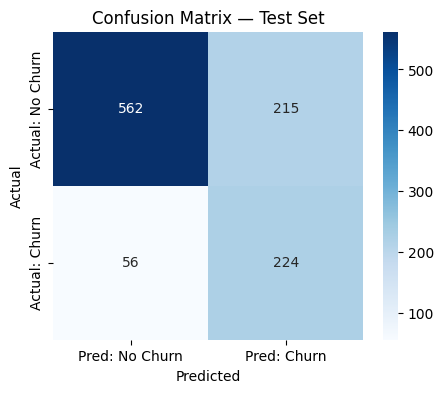

True Negatives:  562  (correctly predicted as staying)
False Positives: 215  (predicted churn, actually stayed)
False Negatives: 56  (predicted stay, actually churned -- the costliest mistake for a retention team)
True Positives:  224  (correctly predicted as churning)


In [36]:
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: No Churn", "Pred: Churn"],
    yticklabels=["Actual: No Churn", "Actual: Churn"]
)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}  (correctly predicted as staying)")
print(f"False Positives: {fp}  (predicted churn, actually stayed)")
print(f"False Negatives: {fn}  (predicted stay, actually churned -- the costliest mistake for a retention team)")
print(f"True Positives:  {tp}  (correctly predicted as churning)")

**Business framing:** a false negative means we fail to flag a customer who was actually about to leave — the retention team never reaches out, and the company loses that customer with zero warning. A false positive just means a loyal customer gets an unnecessary retention offer (a much cheaper mistake). This is why **recall on the churn class** is often prioritized over raw accuracy in a real churn-prevention deployment — worth a sentence on this in your final remarks.

### 9.2 ROC curve

The ROC curve shows the trade-off between true positive rate (recall) and false positive rate across *every* possible decision threshold, not just the default 0.5 we've been using. AUC (the area under this curve) summarizes that trade-off in a single number.

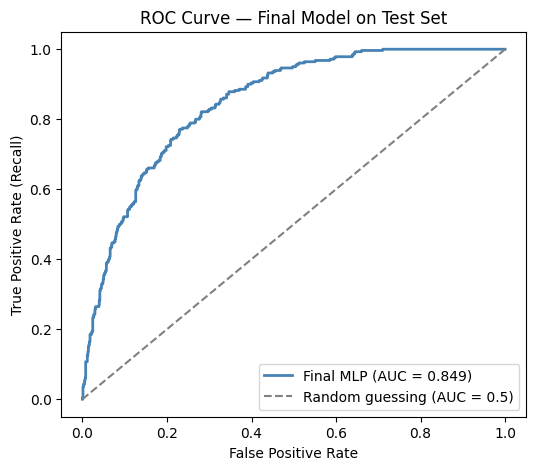

In [37]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, test_probs)
test_auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Final MLP (AUC = {test_auc:.3f})", color="steelblue", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Final Model on Test Set")
plt.legend()
plt.show()

A curve that bows well above the diagonal "random guessing" line confirms the model has learned real, useful signal — not just exploiting class imbalance.

### 9.3 Final comparison: all three models side by side

A clean summary table comparing Logistic Regression, the Step 3 baseline MLP, and the final tuned MLP — all evaluated consistently — is one of the most report-friendly artifacts we can produce.

In [38]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression (baseline)",
        "Accuracy": accuracy_score(y_val, baseline_val_preds),
        "Precision": precision_score(y_val, baseline_val_preds),
        "Recall": recall_score(y_val, baseline_val_preds),
        "F1": f1_score(y_val, baseline_val_preds),
        "AUC": roc_auc_score(y_val, baseline_val_probs),
        "Evaluated on": "Validation"
    },
    {
        "Model": "MLP - Step 3 baseline (32,16)",
        "Accuracy": accuracy_score(y_val, mlp_val_preds),
        "Precision": precision_score(y_val, mlp_val_preds),
        "Recall": recall_score(y_val, mlp_val_preds),
        "F1": f1_score(y_val, mlp_val_preds),
        "AUC": roc_auc_score(y_val, mlp_val_probs),
        "Evaluated on": "Validation"
    },
    {
        "Model": f"MLP - Final tuned ({best_config_name})",
        "Accuracy": accuracy_score(y_test, test_preds),
        "Precision": precision_score(y_test, test_preds),
        "Recall": recall_score(y_test, test_preds),
        "F1": f1_score(y_test, test_preds),
        "AUC": roc_auc_score(y_test, test_probs),
        "Evaluated on": "TEST (final, unbiased)"
    },
])

final_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,AUC,Evaluated on
0,Logistic Regression (baseline),0.742,0.509,0.769,0.613,0.829,Validation
1,"MLP - Step 3 baseline (32,16)",0.756,0.529,0.747,0.619,0.830,Validation
2,"MLP - Final tuned (baseline (32,16) dropout=0....",0.744,0.510,0.800,0.623,0.849,"TEST (final, unbiased)"
